<a href="https://colab.research.google.com/github/abiramig1821-pixel/Social-Media-Engagement-Analytics-using-Python/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Data Analytics (DA)**

## **Module End  Assignment: Python For Data Analysis**

## **“Social Media Engagement Analytics”**


**Project Title:** Social Media Engagement Analytics Using Python

**Problem Statement**

  Social media platforms generate massive volumes of engagement data—likes, comments, shares, impressions, watch time, and more. Analyzing such data helps companies understand user behavior, identify trends, and improve content performance.

  In this assignment,will work with a social media dataset containing social media engagement metrics. The task involves data cleaning, transformation, NumPy/Pandas operations, exploratory data analysis, visualizations, and generating insights.

Dataset Link: https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv

 ## Tasks:

    ❖ Task 1 — Data Import & Setup
    
    ❖ Task 2 — Data Cleaning

    ❖ Task 3 — Data Exploration using Pandas

    ❖ Task 4 — Data Wrangling  

    ❖ Task 5 — Statistical Analysis  

    ❖ Task 6 — Data Visualization (Min. 8 Plots Required)

    ❖ Final Insights should include the following analysis
    

### ❖ Task 1 — Data Import & Setup
    
    ○ Import CSV using Pandas
    ○ Check/convert data types
    ○ Convert date columns to datetime

**Import CSV using Pandas**

In [1]:
pip install numpy pandas

In [2]:
import pandas as pd
import numpy as np


In [3]:
data=pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv")


In [4]:
data

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [5]:
data.shape

(5000, 19)

**Check/convert data types**

In [6]:
data.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


Here, age column as in folat64 datatype i needs to convert as int64 datatype.

In [7]:
# data['age']=data['age'].astype('int')

while i am executing the above age converting datatypes its shows error causes null values(NAN) Can't be change as int types.So, once the null values handled we can able to convert as integer type.

**Convert date columns to datetime**

In [8]:
data['posted_at']=pd.to_datetime(data['posted_at'], dayfirst=True)

In [9]:
data['posted_at'].dtypes

dtype('<M8[ns]')

### ❖ Task 2 — Data Cleaning

* **Cleaning Missing Data**

    * Detect missing values (isnull(), isna())
    * Handle using: dropna(), fillna(), median/mode, forward/backward-fill
* **Duplicate Handling-**
   * Identify & remove duplicates
* **Data Formatting**
    * Fix incorrect data types
    * Standardize categories (e.g., gender labels)
    * Correct unrealistic values in likes, comments, shares
* **Feature Cleaning**
    * Extract hashtag count
    * Clean sentiment labels

In [10]:
# Cleaning Missing Data

# Detect missing values

data.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


Handle null values with mean, mode, median, unknown

In [11]:
data[data.isnull().any(axis=1)]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
8,54131,54.0,Female,UK,907449,image,fashion,NaN,2379.0,1897.0,5650,36283,2023-07-06,615809,True,desktop,negative,#music #fun #fitness,0.533914
17,74925,13.0,Male,Germany,980370,text,lifestyle,6704.0,2804.0,NaN,4394,63141,2023-05-01,212134,False,mobile,positive,#foodie #fun #lifestyle,0.181087
36,41551,NaN,Male,UAE,838360,text,fitness,5168.0,1486.0,1144.0,2750,12440,2022-09-17,562099,False,tablet,neutral,#music #lifestyle #love,0.626849
41,90038,29.0,NaN,UK,147547,video,food,19918.0,2859.0,1903.0,3043,73974,2023-01-18,133257,False,desktop,negative,#tech #fun #foodie,0.333631
48,33897,NaN,Female,USA,544056,video,music,2572.0,2777.0,267.0,2429,88819,2022-03-13,721632,False,desktop,neutral,#tech #music #foodie,0.063230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4936,74729,13.0,Female,USA,898526,video,travel,NaN,1684.0,1726.0,4399,47864,2023-09-12,345434,False,tablet,positive,#reels #music,0.176187
4941,90072,35.0,Other,Australia,521350,reel,fitness,5646.0,NaN,1233.0,4373,46479,2023-04-24,666979,False,desktop,neutral,#tech,0.164590
4960,47842,28.0,Male,India,221952,video,fashion,NaN,2999.0,5.0,3124,28035,2022-11-20,139180,False,mobile,neutral,#foodie #music #tech,0.235741
4964,43037,38.0,NaN,UK,817414,video,fashion,9152.0,760.0,579.0,4247,79732,2022-06-28,484860,False,mobile,neutral,#fashion #music #tech,0.131578


In [12]:
data.select_dtypes(include='number').columns

Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')

In [13]:
null_numericcols = ['age','likes','comments','shares']
null_numericcols

['age', 'likes', 'comments', 'shares']

In [14]:
# fill numeric cols of null values ['age', 'likes', 'comments', 'shares'] with mean values

data[null_numericcols]=data[null_numericcols].fillna(data[null_numericcols].mean())

In [15]:
# Nonumerical column of ['sentiment'] column fill with 'Unknown'

data['sentiment']=data['sentiment'].fillna('Unknown')

In [16]:
# For Nonnumerical column of ['gender'] i choose to fill with mode()
data['gender']=data['gender'].fillna(data['gender'].mode()[0])

In [17]:
# Checking null values are filled or
data.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [18]:
# I need to change the datatype of age as
data['age']=data['age'].astype('int')

In [19]:
data['age'].dtypes

dtype('int64')

**Duplicate Handling**

Identify & remove duplicates

In [20]:
data.duplicated().sum()

np.int64(0)

There is no more dupilicate values in the dataset




**Data Formatting**
    
    ■ Fix incorrect data types
    ■ Standardize categories (e.g., gender labels)
    ■ Correct unrealistic values in likes, comments, shares

In [21]:
# Standardize categories (e.g., gender labels)

categorical_cols = data.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    data[col] = data[col].astype(str).str.strip().str.capitalize()

In [22]:
data.nunique()

,0
user_id,4862
age,52
gender,3
country,10
post_id,4991
post_type,4
post_category,8
likes,4293
comments,2401
shares,1828


In [23]:
#  unique values for categorical columns

for col in data.select_dtypes(include='object').columns:
    print(f"{col}: \n{data[col].unique()[:]}\n")


gender: 
['Female' 'Male' 'Other']

country: 
['Brazil' 'Uk' 'France' 'Canada' 'Japan' 'Australia' 'India' 'Uae'
 'Germany' 'Usa']

post_type: 
['Image' 'Reel' 'Text' 'Video']

post_category: 
['Fitness' 'Food' 'Tech' 'Travel' 'Fashion' 'Lifestyle' 'Education'
 'Music']

device_type: 
['Mobile' 'Tablet' 'Desktop']

sentiment: 
['Negative' 'Positive' 'Neutral' 'Unknown']

hashtags: 
['#foodie #travel #love' '#fitness' '#foodie' '#music #foodie #fun'
 '#travel' '#music' '#travel #music #fitness' '#music #fun #fitness'
 '#lifestyle #love' '#tech' '#fun #fashion #love' '#foodie #lifestyle'
 '#foodie #fashion' '#reels' '#foodie #fun #lifestyle'
 '#love #fashion #fitness' '#foodie #travel #fitness' '#foodie #fitness'
 '#fun' '#reels #fashion' '#fashion' '#fitness #love'
 '#foodie #tech #fitness' '#love #music' '#love #foodie' '#lifestyle'
 '#fashion #fitness #reels' '#reels #tech' '#tech #fitness'
 '#music #lifestyle #love' '#lifestyle #fun #music' '#fitness #tech'
 '#reels #foodie #travel' 

In [24]:
data.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


There is no more incorrect data types, Standardize categories (e.g., gender labels)

In [25]:
numeric_cols=data.select_dtypes(include='number').columns
numeric_cols

Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')

In [26]:
data.select_dtypes(include='object').columns

Index(['gender', 'country', 'post_type', 'post_category', 'device_type',
       'sentiment', 'hashtags'],
      dtype='object')

In [27]:
# Correct unrealistic values(outliers) in likes, comments, shares
# Select the columns first, then describe them
data[['age', 'post_id', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_rate']].describe()


,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,38.440400,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,14.687151,260646.957267,5702.293011,856.392853,570.852962,2308.096459,28844.939104,230927.884535,5.318029
min,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,38.000000,548077.500000,10107.043711,1502.195670,1002.629485,4034.500000,49934.500000,388982.000000,0.253896
75%,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,589744.250000,0.504794
max,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


While seeing descriptive value engagement_rate max value has '191.504348' which shows as outliers. most of the rate been from 0.14578 to 0.504794 but max values(191.504348') is higher.

In [28]:
data[['gender', 'country', 'post_type', 'post_category', 'device_type','sentiment', 'hashtags']].describe()

,gender,country,post_type,post_category,device_type,sentiment,hashtags
count,5000,5000,5000,5000,5000,5000,5000
unique,3,10,4,8,3,4,761
top,Male,India,Reel,Fitness,Mobile,Positive,#tech
freq,1849,535,1283,675,1684,2363,201


In [29]:
pip install matplotlib seaborn

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

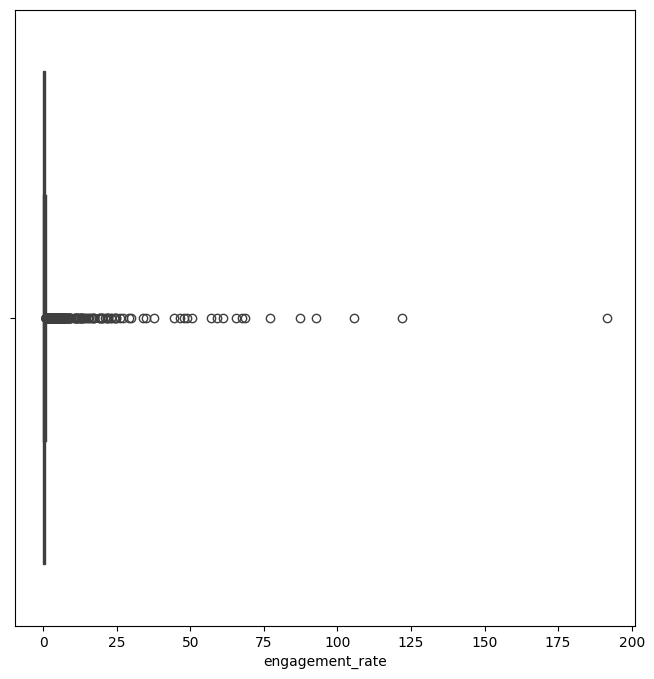

In [31]:
# Finding outlier using boxplot

plt.figure(figsize=(8,8))
sns.boxplot(x=data['engagement_rate'])
plt.show()

Our descriptive values shows clearly 'engagement_rate' has outliers and this box plot shows outliers is there.

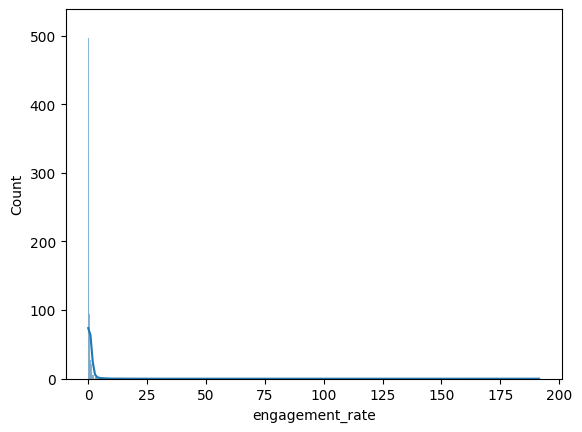

In [32]:
# using kdeplot to see how skewed this enagement_rate column
sns.histplot(data=data['engagement_rate'],kde=True)
plt.show()

while seeing this hist plot also shows as extremely right skewd needs to focus on handling outliers. and also we check with all numeric values of skewness and kurtosis

In [33]:
# Checking skewness

data.skew(numeric_only=True)

,0
user_id,0.033673
age,0.023713
post_id,0.010853
likes,-0.006918
comments,0.003255
shares,-0.013176
watch_time_sec,-0.018196
impression_count,0.015232
follower_count,0.041118
is_verified,2.731918


In [34]:
data.kurtosis(numeric_only=True)

,0
user_id,-1.207199
age,-1.133449
post_id,-1.184294
likes,-1.149992
comments,-1.144373
shares,-1.146855
watch_time_sec,-1.195652
impression_count,-1.198398
follower_count,-1.189474
is_verified,5.465560


In [35]:
# handle ooutliers in engagement_rate column with capping method because

Q1=data['engagement_rate'].quantile(0.25)
Q3=data['engagement_rate'].quantile(0.75)
IQR=Q3-Q1
upper_bound=IQR+1.5*Q3
lower_bound=IQR-1.5*Q1

print(Q1,Q3,IQR,upper_bound,lower_bound,sep="\n\n")



0.14578108750000002

0.504793702

0.35901261449999994

1.1162031675

0.1403409832499999


In [36]:
# capping method

data['engagement_rate'] = np.where(data['engagement_rate'] > upper_bound, upper_bound, data['engagement_rate'])

Here why i am using capping method means, Even i tried IQR methods too.. its reduced the no of rows from 5000 to 3171 rows that will affect furthre analysis. Almost 36% data been removed while handled by IQR method. SO, for the reason o am choosing Capping method

In [37]:
# capping the extreme outliers and stored in actual data

data['engagement_rate'].describe()

,engagement_rate
count,5000.000000
mean,0.384562
std,0.332885
min,0.006363
25%,0.145781
50%,0.253896
75%,0.504794
max,1.116203


In [38]:
# After outliers
data['engagement_rate'].describe()


,engagement_rate
count,5000.000000
mean,0.384562
std,0.332885
min,0.006363
25%,0.145781
50%,0.253896
75%,0.504794
max,1.116203


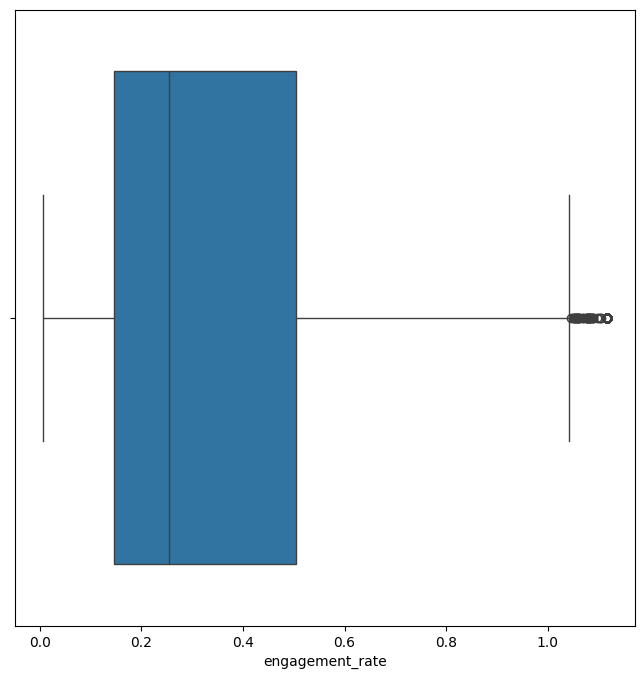

In [39]:
# after huge outliers handled

plt.figure(figsize=(8,8))
sns.boxplot(x=data['engagement_rate'])
plt.show()

After outlier handled also have outliers not extreme and also its not impact furthere analysis

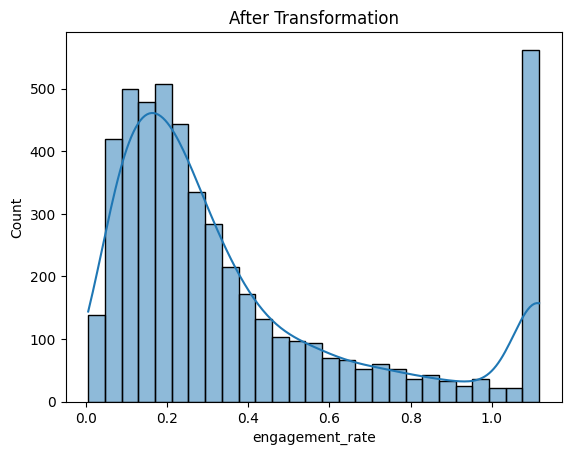

In [40]:
# After outliers handled kdeplot to see how skewed this enagement_rate column
sns.histplot(data['engagement_rate'], kde=True)
plt.title("After Transformation")
plt.show()


#### Feature Cleaning

    ■ Extract hashtag count
    
    ■ Clean sentiment labels

In [41]:
# Extract hashtag count

data['hashtags']

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel
...,...
4995,#travel #fun
4996,#foodie #reels
4997,#lifestyle #tech
4998,#reels #love #fitness


In [42]:
data['sentiment'].value_counts()

,count
sentiment,
Positive,2363
Neutral,1527
Negative,960
Unknown,150


By seeinhg this value counts we get know we cleaned the sentiment data before its done.

### ❖ Task 3 — Data Exploration using Pandas

**Perform the following:**
    
    ● View dataset structure using head(), tail(), shape, and columns.
    
    ● Check data types and info with info() and dtypes.
    
    ● Generate summary statistics using describe().
    
    ● Analyze categorical distributions using value_counts(), unique(), and nunique().
    
    ● Create a correlation matrix for numeric fields.
    
    ● Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

In [43]:
# View dataset structure using head(), tail(), shape, and columns.
data.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,Image,Fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,Reel,Food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32,Female,Uk,109864,Text,Food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51,Other,France,848877,Text,Fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34,Other,Uk,449706,Image,Fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,1.116203


In [44]:
#  tail()
data.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44,Male,Australia,441541,Video,Education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761
4996,22100,38,Other,Uae,677076,Reel,Education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155
4997,67021,63,Female,Usa,273595,Text,Travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688
4998,29800,13,Female,Germany,785644,Video,Fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518
4999,73400,54,Other,Japan,712252,Text,Travel,14830.0,503.00000,1798.0,3743,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.116203


In [45]:
# shape
data.shape

(5000, 19)

In [46]:
# Columns
data.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [47]:
# Check data types and info with info() and dtypes.

data.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [49]:
# Generate summary statistics using describe().
data.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.384562
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10107.043711,1502.195670,1002.629485,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,1.116203
std,26090.370121,14.687151,260646.957267,5702.293011,856.392853,570.852962,2308.096459,28844.939104,NaN,230927.884535,0.332885


In [50]:
#  Analyze categorical distributions using value_counts(), unique(), and nunique().

data.select_dtypes(include='object').columns

Index(['gender', 'country', 'post_type', 'post_category', 'device_type',
       'sentiment', 'hashtags'],
      dtype='object')

In [51]:
# Gender  categorical distributions using value_counts(), unique(), and nunique().

for col in data.select_dtypes(include='object').columns:
    print(f"{col}: \n{data[col].unique()[:]}\n")
    print(f'{col}:\n {data[col].nunique()}\n')
    print(f'{col}:\n {data[col].value_counts()[:]} \n')

gender: 
['Female' 'Male' 'Other']

gender:
 3

gender:
 gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64 

country: 
['Brazil' 'Uk' 'France' 'Canada' 'Japan' 'Australia' 'India' 'Uae'
 'Germany' 'Usa']

country:
 10

country:
 country
India        535
Canada       513
Brazil       504
Uae          503
Usa          501
France       496
Uk           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64 

post_type: 
['Image' 'Reel' 'Text' 'Video']

post_type:
 4

post_type:
 post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64 

post_category: 
['Fitness' 'Food' 'Tech' 'Travel' 'Fashion' 'Lifestyle' 'Education'
 'Music']

post_category:
 8

post_category:
 post_category
Fitness      675
Tech         665
Music        635
Education    631
Lifestyle    607
Travel       600
Fashion      594
Food         593
Name: count, dtype: int64 

device_type: 
['Mobile' 'Tablet' 'Desktop']

device_type:
 3

d

In [52]:
data[numeric_cols].columns

Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')

In [53]:
# Create a corelation matrix for numeric fields.

corelation_matrix = data[['age','likes','comments','shares','watch_time_sec','impression_count','follower_count','engagement_rate']].corr()
corelation_matrix= corelation_matrix.corr()
corelation_matrix

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
age,1.000000,-0.259420,-0.150800,-0.113852,-0.125128,0.016615,-0.174807,-0.124073
likes,-0.259420,1.000000,-0.198285,-0.167406,-0.162875,-0.256672,-0.216444,0.506310
comments,-0.150800,-0.198285,1.000000,-0.137927,-0.184123,-0.079343,-0.155210,0.030994
shares,-0.113852,-0.167406,-0.137927,1.000000,-0.124586,-0.065837,-0.164622,0.010037
watch_time_sec,-0.125128,-0.162875,-0.184123,-0.124586,1.000000,-0.040471,-0.126660,-0.043373
impression_count,0.016615,-0.256672,-0.079343,-0.065837,-0.040471,1.000000,-0.043312,-0.954701
follower_count,-0.174807,-0.216444,-0.155210,-0.164622,-0.126660,-0.043312,1.000000,-0.070235
engagement_rate,-0.124073,0.506310,0.030994,0.010037,-0.043373,-0.954701,-0.070235,1.000000


In [54]:
data.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [55]:
# Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

# Best post types, See if videos or images get more traction.
data.groupby('post_type')[['likes', 'comments', 'shares', 'engagement_rate']].count()


,likes,comments,shares,engagement_rate
post_type,,,,
Image,1247,1247,1247,1247
Reel,1283,1283,1283,1283
Text,1245,1245,1245,1245
Video,1225,1225,1225,1225


In [56]:
# groupby post_category: Identify which topics drive the most watch time and visibility.

data.groupby('post_category')[['watch_time_sec', 'impression_count']].agg(['mean', 'sum'])



watch_time_sec          impression_count          
                        mean      sum             mean       sum
post_category                                                   
Education        4064.865293  2564930     49232.115689  31065465
Fashion          4070.067340  2417620     50082.023569  29748722
Fitness          3982.051852  2687885     49150.431111  33176541
Food             3989.146712  2365564     50966.573356  30223178
Lifestyle        3995.995058  2425569     50334.296540  30552918
Music            4106.696063  2607752     49785.692913  31613915
Tech             3998.639098  2659095     50692.517293  33710524
Travel           3906.835000  2344101     49962.335000  29977401

In [57]:
# group by country: Find out where your most active users live
data.groupby('country')['engagement_rate'].count()


,engagement_rate
country,
Australia,493
Brazil,504
Canada,513
France,496
Germany,490
India,535
Japan,472
Uae,503
Uk,493


In [58]:
# groupby age and gender: Look at how different demographics interact in the platform.

data.groupby(['age', 'gender'])[['likes', 'watch_time_sec']].count()


likes  watch_time_sec
age gender                       
13  Female     33              33
    Male       23              23
    Other      26              26
14  Female     42              42
    Male       35              35
...           ...             ...
63  Male       29              29
    Other      27              27
64  Female     26              26
    Male       35              35
    Other      36              36

[156 rows x 2 columns]

In [59]:
# groupby verification status  Compare the follower count and impression count.

data.groupby('is_verified')[['follower_count', 'impression_count']].mean()


,follower_count,impression_count
is_verified,,
False,395042.837503,49935.288244
True,381123.451346,50747.343685


In [60]:

# groupby device_type, to See if mobile vs. desktop which highly recommended

data.groupby('device_type')['watch_time_sec'].mean()


,watch_time_sec
device_type,
Desktop,3974.792521
Mobile,4087.830760
Tablet,3979.736429


In [61]:
# Sentiment impact: Do positive, negative, or neutral posts get more shares
data.groupby('sentiment')['shares'].mean()


,shares
sentiment,
Negative,1007.073029
Neutral,996.319698
Positive,1001.543591
Unknown,1055.530863


In [62]:
analysis = data.groupby('post_category').agg({
    'post_id': 'count',           # Total posts in this category
    'likes': 'sum',               # Total likes
    'watch_time_sec': 'mean',     # Average watch time
    'engagement_rate': 'max'      # Highest engagement rate achieved
}).rename(columns={'post_id': 'total_posts'})

print(analysis)


               total_posts         likes  watch_time_sec  engagement_rate
post_category                                                            
Education              631  6.389843e+06     4064.865293         1.116203
Fashion                594  5.846982e+06     4070.067340         1.116203
Fitness                675  6.692380e+06     3982.051852         1.116203
Food                   593  6.063772e+06     3989.146712         1.116203
Lifestyle              607  6.179641e+06     3995.995058         1.116203
Music                  635  6.480676e+06     4106.696063         1.116203
Tech                   665  6.764117e+06     3998.639098         1.116203
Travel                 600  6.117809e+06     3906.835000         1.116203


In [63]:
# groupby Sentiment See if negative posts get more engagement in certain categories while positive posts win in others

data.groupby(['post_category', 'sentiment'])['engagement_rate'].mean().unstack()


sentiment,Negative,Neutral,Positive,Unknown
post_category,,,,
Education,0.369809,0.369790,0.413921,0.358013
Fashion,0.408913,0.385962,0.359431,0.290990
Fitness,0.403150,0.427805,0.380006,0.472945
Food,0.375811,0.357636,0.375387,0.320518
Lifestyle,0.417498,0.397515,0.366041,0.295505
Music,0.390499,0.385112,0.405998,0.310172
Tech,0.357831,0.381842,0.401159,0.305520
Travel,0.392159,0.394667,0.362487,0.364045


In [64]:
# Groupby 'device_type', 'post_type' to which post_type the watch_time_sec is high

data.groupby(['device_type', 'post_type'])['watch_time_sec'].mean().unstack()


post_type,Image,Reel,Text,Video
device_type,,,,
Desktop,3829.955654,4234.128866,3880.516129,3981.264423
Mobile,3910.923664,4207.078261,4121.622328,4088.914634
Tablet,3910.330025,3972.505747,4024.907363,4010.060150


In [65]:
# Groupby month or year  Activity: Find which month is high no.of post based on when engagement peaks or can can we daywise also by using to_day func

data.groupby(data['posted_at'].dt.month)['engagement_rate'].count()


,engagement_rate
posted_at,
1,449
2,393
3,397
4,417
5,390
6,429
7,416
8,455
9,415


In [66]:
# groupby  posted_at; See if weekends perform better than weekdays

data.groupby(data['posted_at'].dt.day_name())['impression_count'].mean()


,impression_count
posted_at,
Friday,49430.537827
Monday,50013.224928
Saturday,50945.228095
Sunday,50345.670782
Thursday,48119.289398
Tuesday,51308.589849
Wednesday,49857.990000


while seeing this shows highest from Tuesday '51308.589849' next Saturday '50945.228095' and next the Monday '50013.224928'. all day performing we can't say weekend performing better

In [67]:
# Groupby age wise how they are activly response
# Interaction Type Ratio: See if certain age groups prefer sharing content over commenting.

data.groupby('age')[['comments', 'shares']].sum()


,comments,shares
age,,
13,111423.587010,84484.517938
14,163363.391340,99404.517938
15,130522.782680,88568.406392
16,125985.391340,86779.629485
17,138363.195670,85626.258969
18,151050.587010,97433.888454
19,139347.587010,78901.517938
20,126246.391340,76183.629485
21,119512.587010,88551.258969


#### ❖ Task 4 — Data Wrangling  
        
        ● Use merge, concat, or join if combining DataFrames.
        
        ● Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.
        
        ● Perform groupby summaries by post_type, country, and sentiment.

In [68]:
#  Create new fields such as hashtag count, age_level

data['hashtag_count'] = data['hashtags'].fillna('').astype(str).str.count('#')

# Age_level column

bins = [0, 18, 35, 55, 120]
labels = ['Teen', 'Young Adult', 'Middle Aged', 'Senior']
data['age_level'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)


In [69]:
data.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'age_level'],
      dtype='object')

#### ❖ Task 5 — Statistical Analysis  

    Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:
        
        ● Mean, median, mode
        ● Standard deviation, variance
        ● Percentiles
        ● (Optional) Skewness and kurtosis



In [70]:
data[numeric_cols].describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.384562
std,26090.370121,14.687151,260646.957267,5702.293011,856.392853,570.852962,2308.096459,28844.939104,230927.884535,0.332885
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10107.043711,1502.195670,1002.629485,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,1.116203


In [71]:
data.skew(numeric_only=True)

,0
user_id,0.033673
age,0.023713
post_id,0.010853
likes,-0.006918
comments,0.003255
shares,-0.013176
watch_time_sec,-0.018196
impression_count,0.015232
follower_count,0.041118
is_verified,2.731918


0 to + or - 0.5 - Symmetric
±0.5 to ±1.0 or slightly above - Moderate Skewness
Beyond ±1.0 - High Skewness

The age, likes, comments, shares, watch_time_sec, impression_count, follower_count, and hashtag_count are highly symmetrical  distribution.

engagement_rate     1.200551 - highly skewd right

In [72]:
data.kurtosis(numeric_only=True)

,0
user_id,-1.207199
age,-1.133449
post_id,-1.184294
likes,-1.149992
comments,-1.144373
shares,-1.146855
watch_time_sec,-1.195652
impression_count,-1.198398
follower_count,-1.189474
is_verified,5.465560


-0.5 and +0.5 - normal
±1.0 and ±2.0 or slightly beyond - Noticeably Non-Normal
Beyond ±2.0 to ±3.0 - Extreme Outlier / Heavy Non-Normality

Here is_verified-5.465560 highly kurtosis.nut its binary value not considered as outliers.

#### ❖ Task 6 — Data Visualization (Min. 8 Plots Required)

    ● Matplotlib ○ Scatter: likes vs impressions
    
        ○ Line: daily engagement trend
        
        ○ Bar: posts by category
        
        ○ Pie: gender distribution ○ Histogram: age
        
        ○ Box: engagement rate
    
    ● Seaborn ○ Count plot: post type
        
        ○ Bar plot: avg likes by category
        
        ○ Violin: followers vs sentiment
        
        ○ Pair plot: numeric features
        
        ○ Heatmap: correlation matrix ○ Swarm plot: engagement vs device
        
    ● Plotly (Interactive)
        
        ○ Interactive line chart/bar chart/bubble/scatter chart

##### **Matplotlib**

    ○ Scatter: likes vs impressions

    ○ Line: daily engagement trend
    
    ○ Bar: posts by category
    
    ○ Pie: gender distribution
    
    ○ Histogram: age
    
    ○ Box: engagement rate

In [73]:
data.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'age_level'],
      dtype='object')

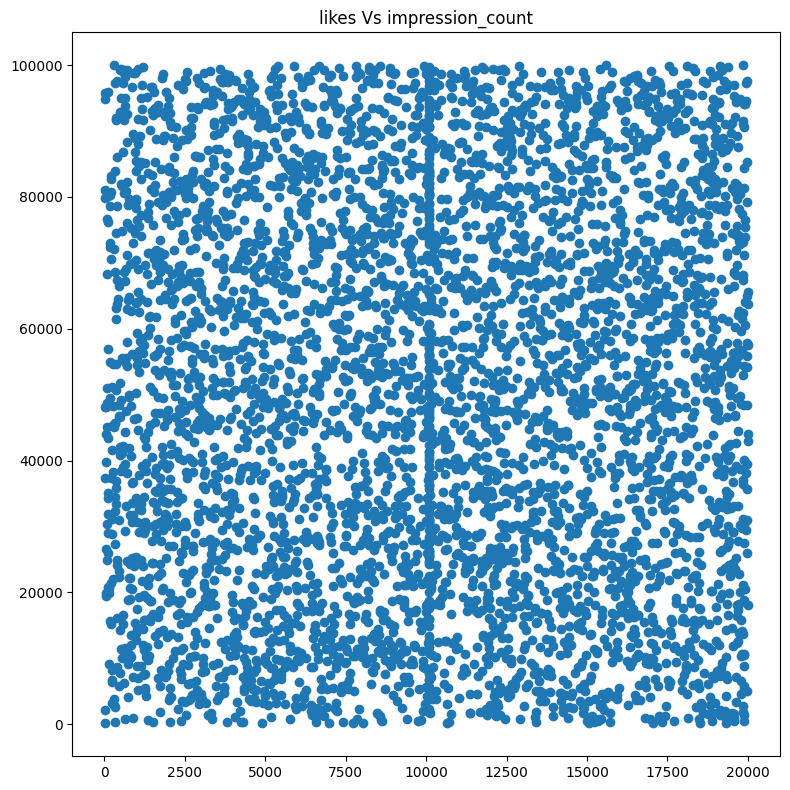

In [74]:
# Scatter: likes vs impressions

plt.figure(figsize=(8,8))
plt.scatter(x=data['likes'], y=data['impression_count'])
plt.title("likes Vs impression_count")
plt.tight_layout()
plt.show()

By using scatter we can able to some relationship there likes vs impression at the point of '10000'.

In [75]:
# ○ Line: daily engagement trend
daily_trend = data.groupby('posted_at')['engagement_rate'].mean().reset_index()
daily_trend

,posted_at,engagement_rate
0,2022-01-01,0.727400
1,2022-01-02,0.413925
2,2022-01-03,0.391243
3,2022-01-04,0.157607
4,2022-01-05,0.408271
...,...,...
724,2023-12-27,0.580355
725,2023-12-28,0.283869
726,2023-12-29,0.428995
727,2023-12-30,0.192192


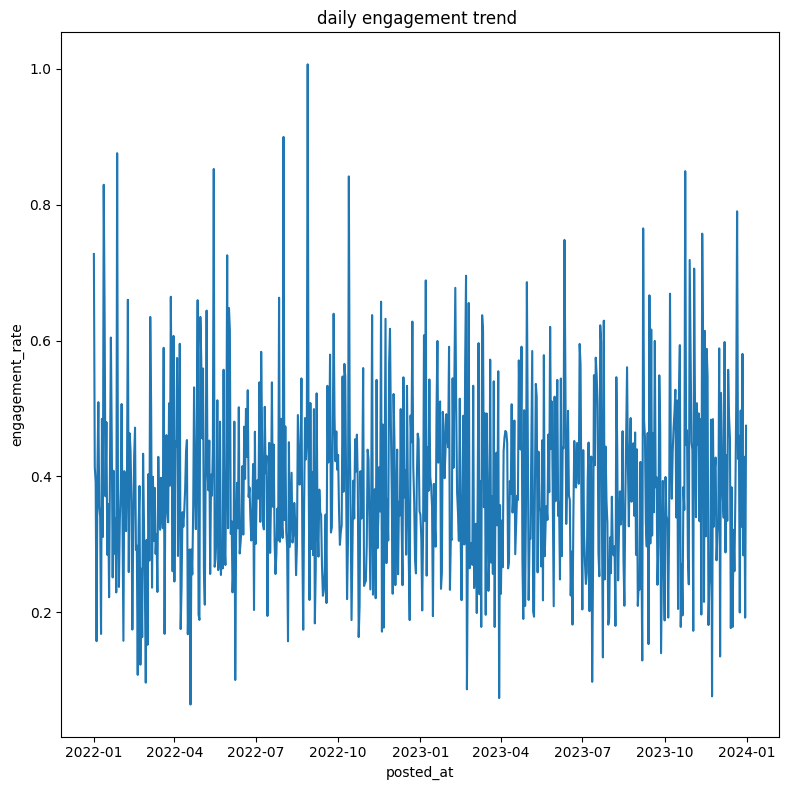

In [76]:
# line plot

plt.figure(figsize=(8,8))
plt.plot(daily_trend['posted_at'],daily_trend['engagement_rate'])
plt.xlabel('posted_at')
plt.ylabel('engagement_rate')
plt.title('daily engagement trend ')
plt.tight_layout()
plt.show()

There is no anyother pattern.

In [77]:
# Bar: posts by category

post= data.groupby('post_category')[['watch_time_sec']].mean().reset_index()
post

,post_category,watch_time_sec
0,Education,4064.865293
1,Fashion,4070.067340
2,Fitness,3982.051852
3,Food,3989.146712
4,Lifestyle,3995.995058
5,Music,4106.696063
6,Tech,3998.639098
7,Travel,3906.835000


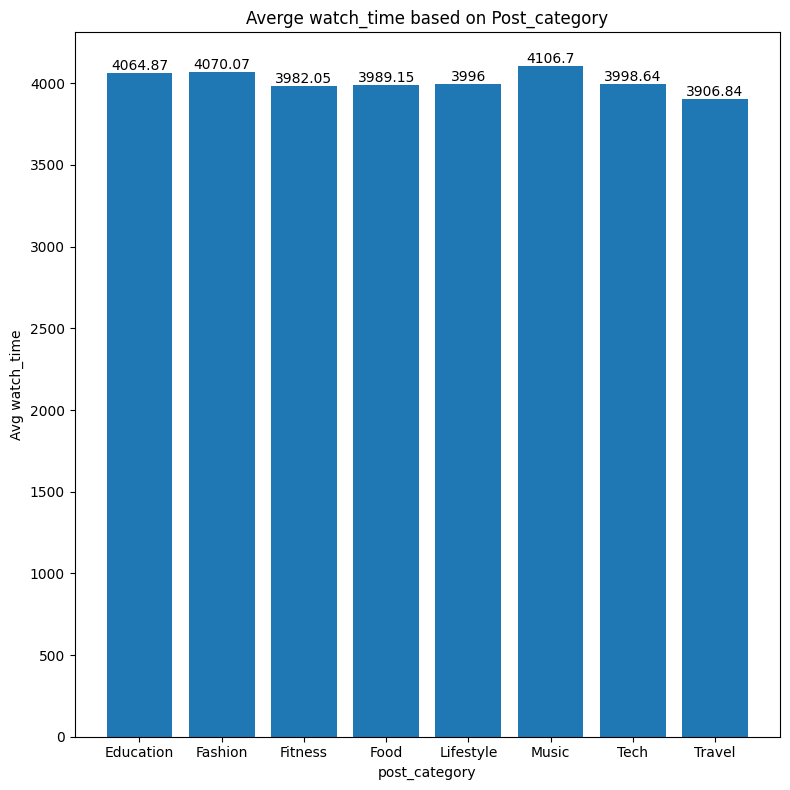

In [78]:
# Bar plot: Post_category
plt.figure(figsize=(8,8))
bars=plt.bar(post['post_category'],post['watch_time_sec'])
plt.bar_label(bars)
plt.title("Averge watch_time based on Post_category")
plt.xlabel('post_category')
plt.ylabel('Avg watch_time')
plt.tight_layout()
plt.show()

Here we can able to see music is higher there is no other pattern. all category driven the same avg.

In [79]:
#  Pie: gender distribution by watwatch_time_sec

gender=data.groupby('gender')['watch_time_sec'].mean()
gender

,watch_time_sec
gender,
Female,3947.747134
Male,4025.950243
Other,4067.407337


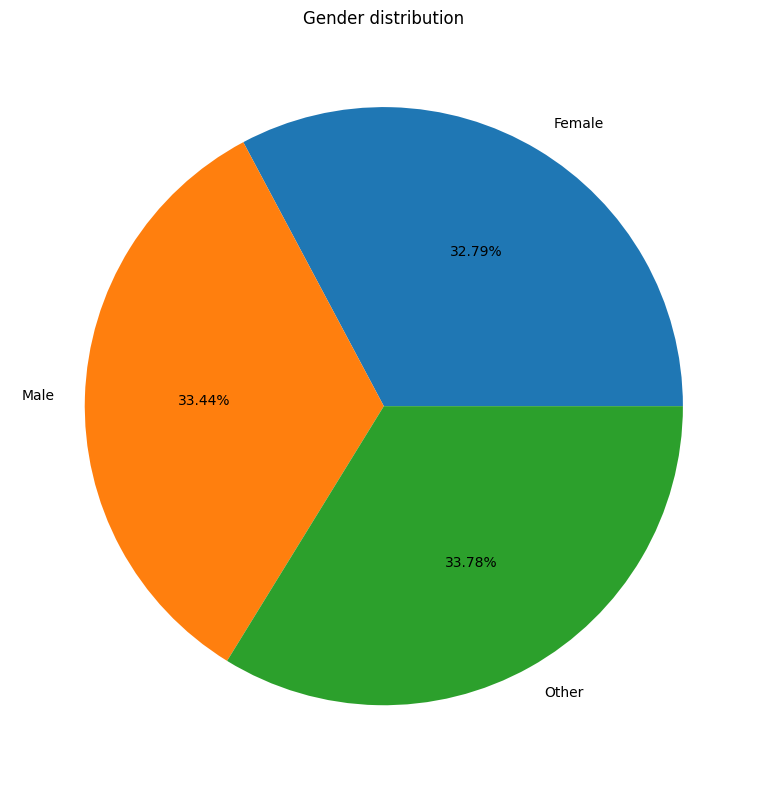

In [80]:
# pie plot

plt.figure(figsize=(8,8))
plt.pie(gender,labels=gender.index,autopct="%1.2f%%")
plt.title("Gender distribution")
plt.tight_layout()
plt.show()

while seeing gender distribution based on watch_time_sec there equaly distributed in each gender.

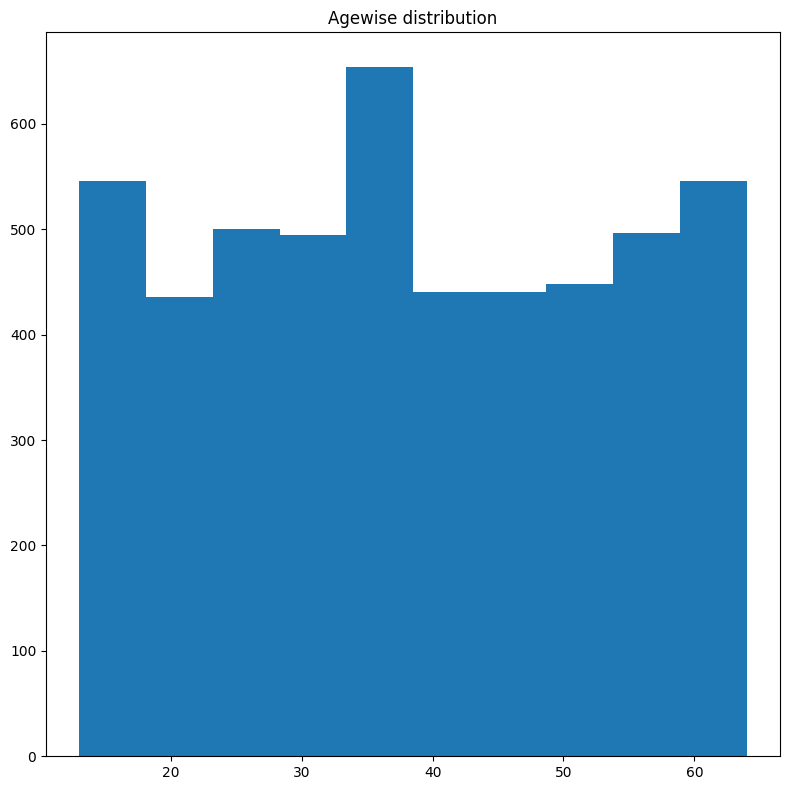

In [81]:
# Histogram: age

plt.figure(figsize=(8,8))
plt.hist(data["age"],bins=10)
plt.title("Agewise distribution")
plt.tight_layout()
plt.show()

here we can able to see 35 to 45 age is higher we already have age_level based on that 'Middle Aged,Young Adult' is high.

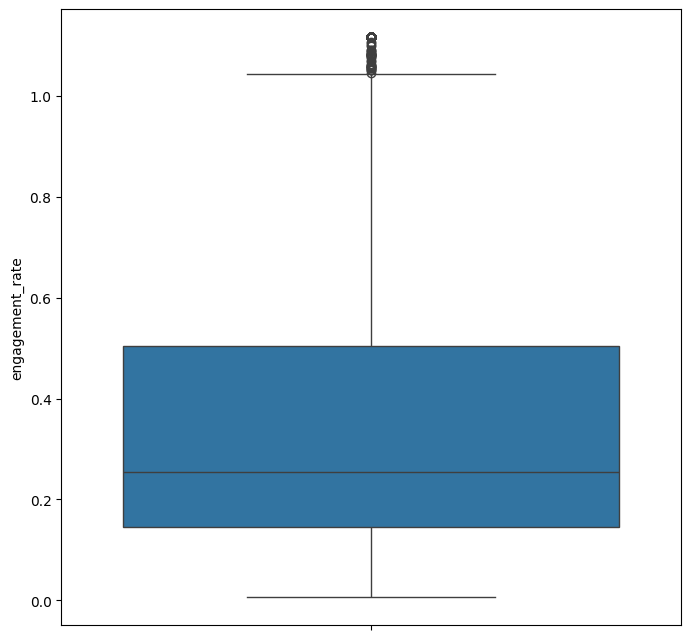

In [82]:
# Box: engagement rate

plt.figure(figsize=(8,8))
sns.boxplot(data['engagement_rate'])
plt.show()

At the time cleaning the dataset we monitor and handled extreme outliers.Even we can able see outliers here also but its not much affceted for furthere analysis.

* **Seaborn**

    ○ Count plot: post type
    
    ○ Bar plot: avg likes by category
    
    ○ Violin: followers vs sentiment
    
    ○ Pair plot: numeric features
    
    ○ Heatmap: correlation matrix

    ○ Swarm plot: engagement vs device

In [83]:
import seaborn as sns

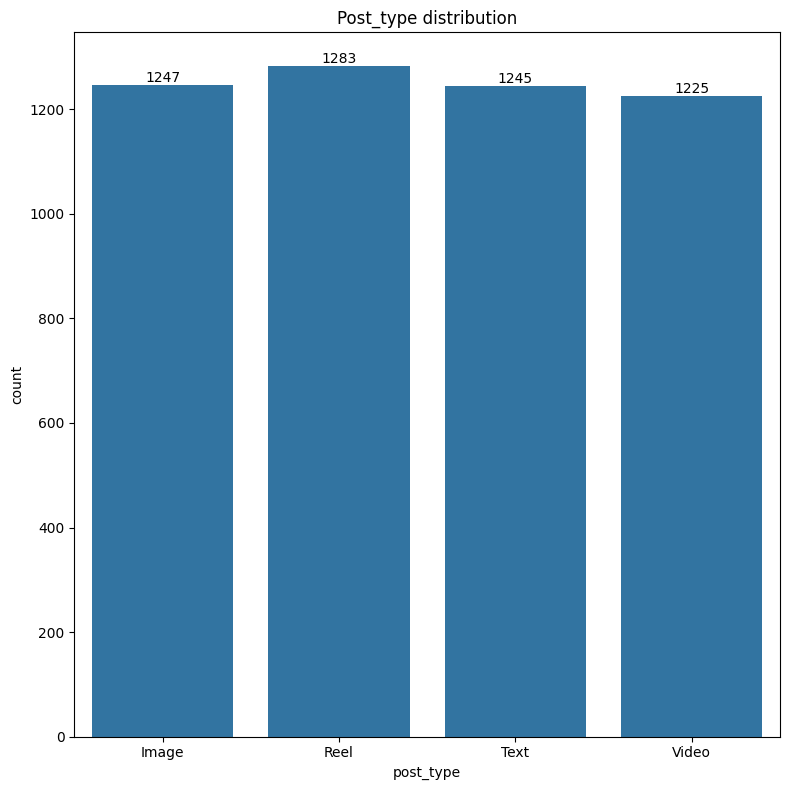

In [84]:
# Count plot: post type

plt.figure(figsize=(8,8))
ax=sns.countplot(data=data,x="post_type")
plt.bar_label(ax.containers[0])
plt.title("Post_type distribution")
plt.tight_layout()
plt.show()


Here there is not much different from each type its all almose near the same distribution.

In [85]:
# Bar plot: avg likes by category
avg_likes = data.groupby(['post_category'])['likes'].mean()
avg_likes

,likes
post_category,
Education,10126.533804
Fashion,9843.403681
Fitness,9914.636527
Food,10225.585243
Lifestyle,10180.627974
Music,10205.788503
Tech,10171.603928
Travel,10196.347905


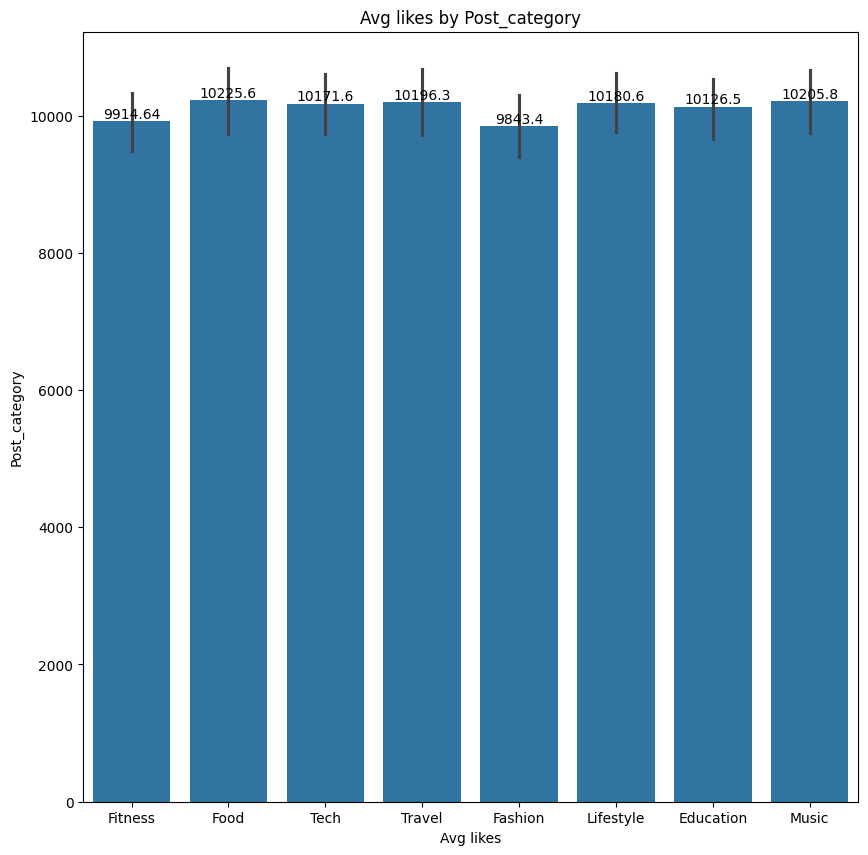

In [86]:
# Bar Plot avg likes by postcategory

plt.figure(figsize=(10,10))
ax=sns.barplot(data=data,x="post_category",y='likes')
plt.bar_label(ax.containers[0])
plt.title("Avg likes by Post_category")
plt.xlabel('Avg likes')
plt.ylabel('Post_category')
plt.show()

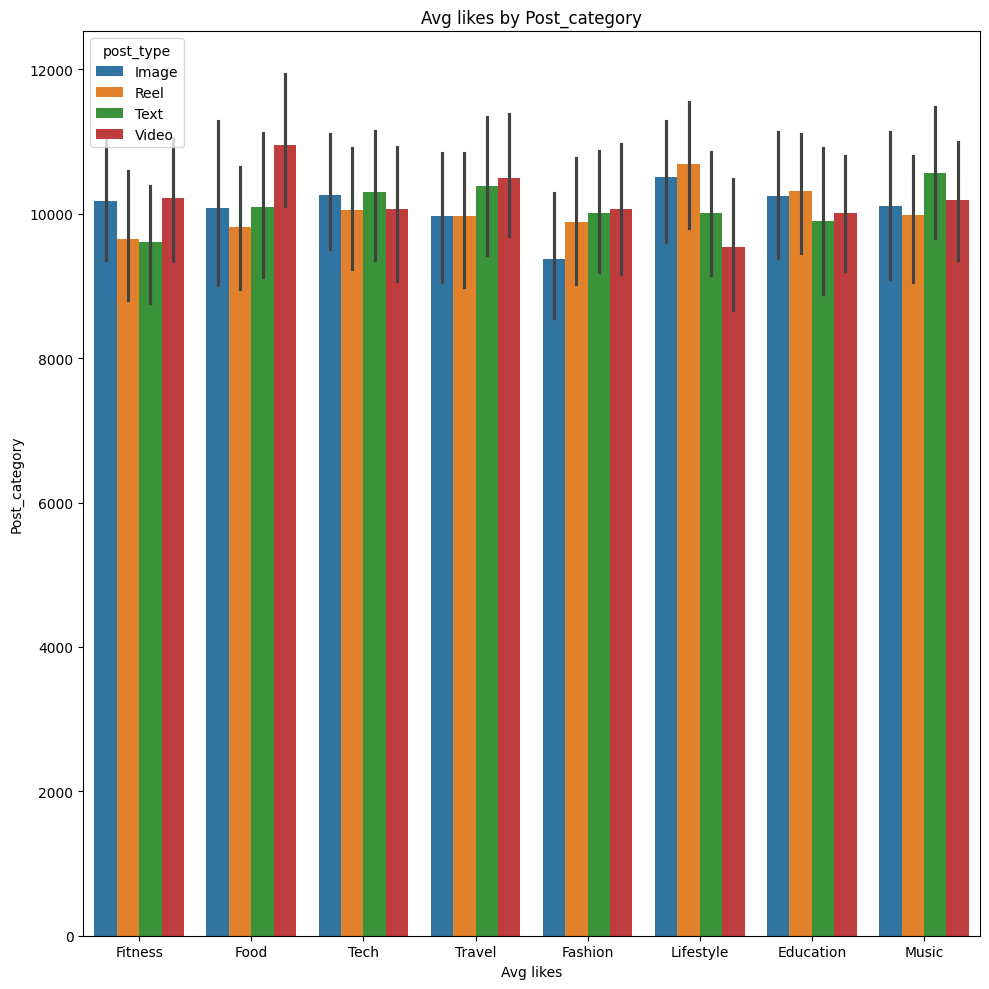

In [87]:
# Here i used to differentiate by post_type

plt.figure(figsize=(10,10))
sns.barplot(data=data,x="post_category",y='likes', hue='post_type')
plt.title("Avg likes by Post_category")
plt.xlabel('Avg likes')
plt.ylabel('Post_category')
plt.tight_layout()
plt.show()

In [88]:
#  Violin: followers vs sentiment
data.groupby('sentiment')['follower_count'].mean()

,follower_count
sentiment,
Negative,397430.429167
Neutral,390568.446627
Positive,393242.916208
Unknown,408845.886667


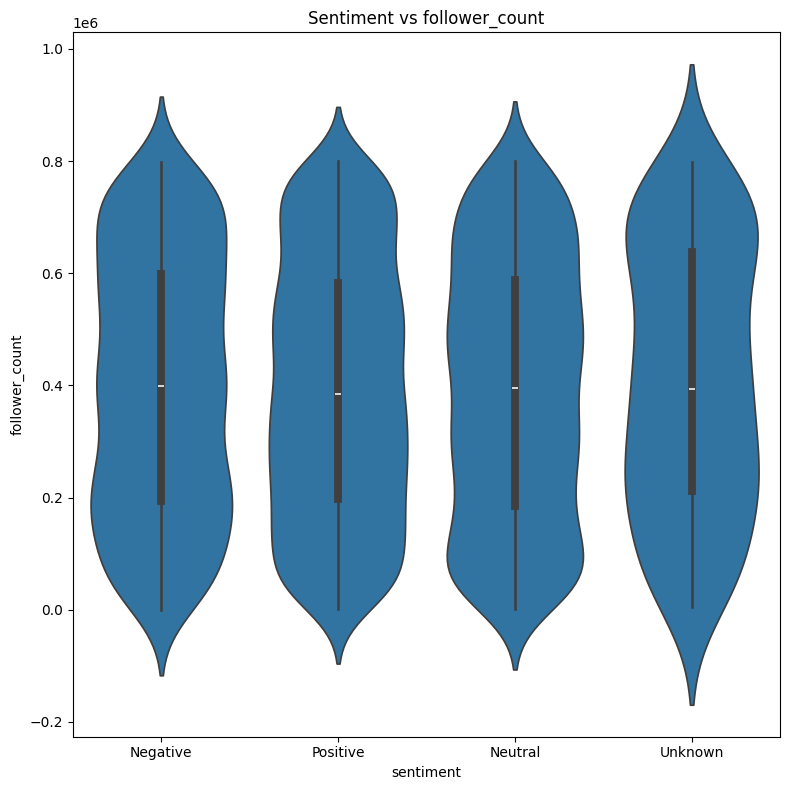

In [89]:
# violin plot

plt.figure(figsize=(8,8))
sns.violinplot(data=data,x='sentiment', y='follower_count')
plt.title("Sentiment vs follower_count")
plt.tight_layout()
plt.show()

while seeing the distribution of sentiment vs follower_count each sentiment most equaly distibuted we can't able to say which much high or more less.

In [90]:
numeric_cols

Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')

In [91]:
c_data=data.copy()

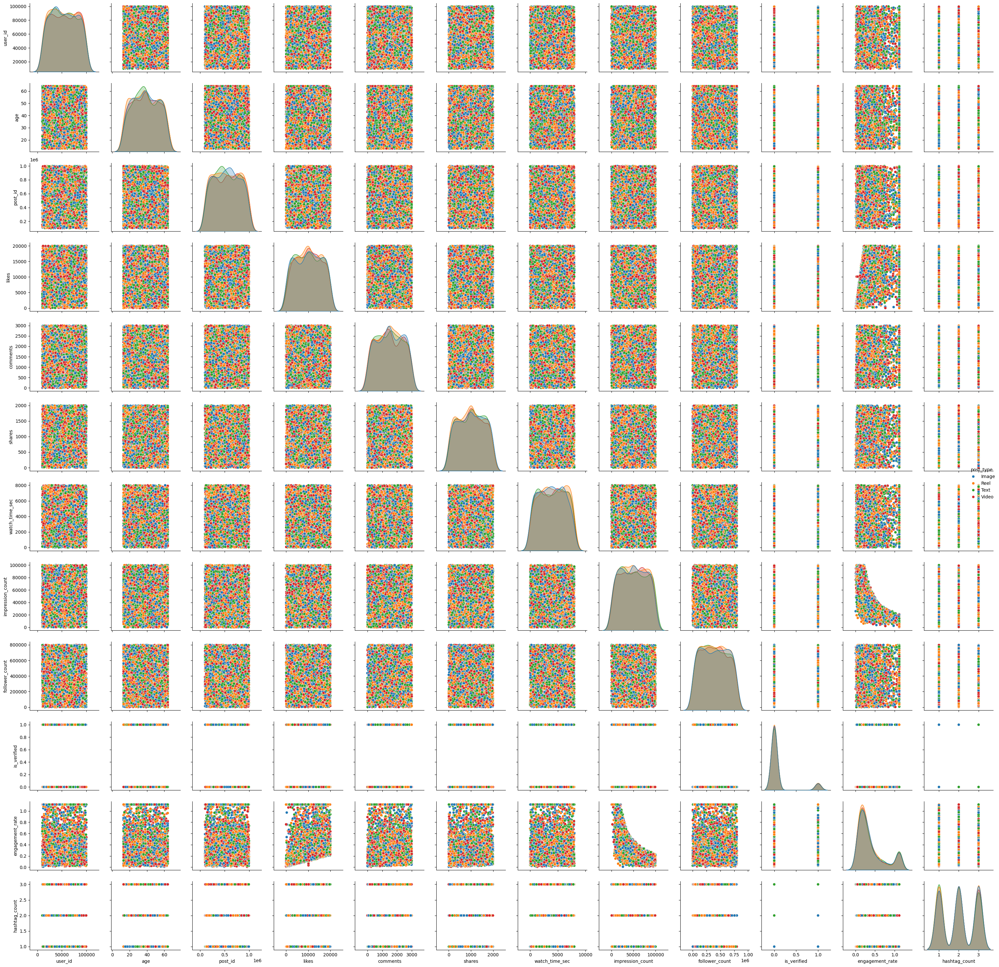

In [92]:
# Pair plot: numeric features

sns.pairplot(data=c_data, hue='post_type')
plt.title("")
plt.tight_layout()
plt.show()


In [93]:
# Heatmap: correlation matrix
corelation_matrix

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
age,1.000000,-0.259420,-0.150800,-0.113852,-0.125128,0.016615,-0.174807,-0.124073
likes,-0.259420,1.000000,-0.198285,-0.167406,-0.162875,-0.256672,-0.216444,0.506310
comments,-0.150800,-0.198285,1.000000,-0.137927,-0.184123,-0.079343,-0.155210,0.030994
shares,-0.113852,-0.167406,-0.137927,1.000000,-0.124586,-0.065837,-0.164622,0.010037
watch_time_sec,-0.125128,-0.162875,-0.184123,-0.124586,1.000000,-0.040471,-0.126660,-0.043373
impression_count,0.016615,-0.256672,-0.079343,-0.065837,-0.040471,1.000000,-0.043312,-0.954701
follower_count,-0.174807,-0.216444,-0.155210,-0.164622,-0.126660,-0.043312,1.000000,-0.070235
engagement_rate,-0.124073,0.506310,0.030994,0.010037,-0.043373,-0.954701,-0.070235,1.000000


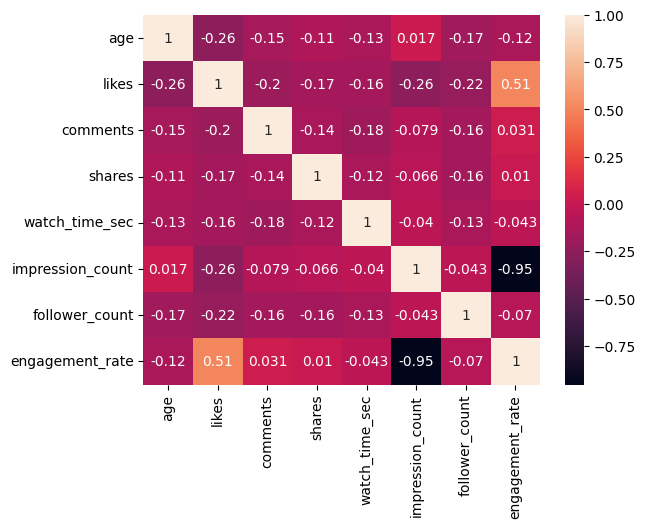

In [94]:
sns.heatmap(corelation_matrix,annot=True)
plt.show()


Based on the heatmap we can able see how the relationship of numerica cols has,

  Extremely Strong Negative - impression_count & engagement_rate-0.95 - High visibility significantly dilutes the engagement percentage.Moderate

  Positive - likes & engagement_rate - 0.51- More likes directly reflect a healthier engagement rate.
  
  Weak Negative - age & likes - -0.26 - Weak tendency for older users to like posts less frequently.
  
  Weak Negative - likes & impression_count - -0.26 - higher but this likes don't automatically scale with massive impressions here.
  
  Almost Zero / None - age & impression_count - 0.017 - User age has zero statistical impact on how many impressions a post receives.

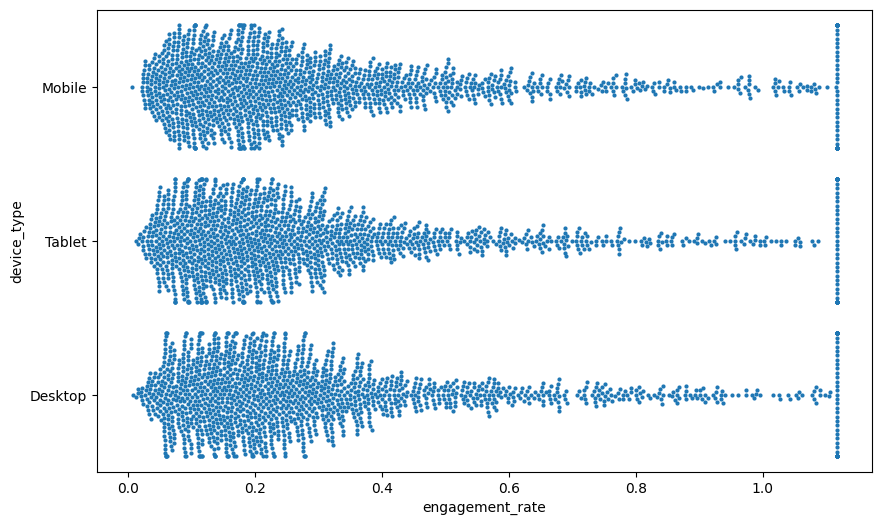

In [95]:
#  Swarm plot: engagement vs device
import warnings
warnings.filterwarnings("ignore", message=".*points cannot be placed.*")

plt.figure(figsize=(10, 6))
sns.swarmplot(data=data, x='engagement_rate', y='device_type', size=3)
plt.show()

This plot shows that Mobile, Tablet, and Desktop share an almost identical distribution, with the vast majority of data points heavily clustered at the lower end between 0.0 and 0.4.

The data is strongly right-skewed and features a distinct upper threshold limit at approximately 1.1 where the values abruptly stop.

In [99]:
# Install plotly

In [103]:
data['watch_time_hours'] = data['watch_time_sec'] / 3600
data['watch_time_hours']

,watch_time_hours
0,1.590556
1,1.651944
2,1.929444
3,0.063611
4,1.332778
...,...
4995,1.719444
4996,2.156667
4997,2.073889
4998,1.386389


In [104]:

import plotly.express as px


data_daily = data.groupby(data['posted_at'].dt.date)['watch_time_hours'].mean().reset_index()

In [108]:
# Plotly line plot


fig = px.line(data_daily, x="posted_at",y="watch_time_hours", title="Daily Total Watch Time Trend",
    labels={"posted_at": "Date", "watch_time_sec": "Total Watch hours"}
)

fig.show()


In [111]:
data.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'age_level', 'watch_time_hours'],
      dtype='object')

In [112]:
# plotly bar chart

fig = px.bar(
    data,
    x="country",
    y="follower_count",
    title="Country wise Follower_count",
    text_auto='.1f'
)

fig.show()


In [113]:
data.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'age_level', 'watch_time_hours'],
      dtype='object')

In [118]:
# Bubble chart
bubble_c = data.groupby('country').agg({ 'impression_count':'mean',
                              'follower_count':'mean',
                              'watch_time_hours':'sum',
                              'engagement_rate':'mean'}).reset_index()

bubble_c

,country,impression_count,follower_count,watch_time_hours,engagement_rate
0,Australia,48346.383367,388979.827586,568.411944,0.412300
1,Brazil,49193.174603,407251.339286,566.888889,0.389352
2,Canada,48703.150097,386956.912281,570.526667,0.390204
3,France,51727.673387,378857.872984,550.111944,0.382349
4,Germany,48605.406122,396641.279592,541.229167,0.390673
5,India,52462.386916,416429.472897,596.946389,0.348661
6,Japan,49616.135593,390841.436441,508.499722,0.399774
7,Uae,48928.413519,402228.644135,559.981944,0.397904
8,Uk,51119.393509,378833.190669,564.032222,0.366378
9,Usa,51263.872255,387904.329341,549.070000,0.371386


In [122]:
# Bubble plot

fig = px.scatter(
    bubble_c,
    x="impression_count",
    y="engagement_rate",
    size="watch_time_hours",
    color="country",
    hover_name="country",
    size_max=50,
    title="Country Performance: Reach vs. Engagement vs. Watch Time",
    labels={
        "impression_count": "Average Impressions (Reach)",
        "engagement_rate": "Average Engagement Rate",
        "watch_time_hours": "Total Watch Time (Hours)"
    }
)

fig.show()

Here we can able to understand country Australia is higher, top-performing country on the chart when it comes to keeping an audience actively involved.

Even though Australia has the lowest average reach on the X-axis (around 48.3k impressions), it commands the absolute highest position on the Y-axis with an Average Engagement Rate of roughly 0.415.

Based on this chart, India is your absolute leader in reach, but it has the lowest audience interaction quality.

Because the bubble sits at the very bottom of the Y-axis, India has the lowest average engagement rate (~0.35). While millions of eyes see the posts, a much smaller percentage of those people stop to like, comment, or share them.

In [130]:
scatter_c = data.groupby('post_category').agg({
    'likes': 'mean',
    'shares': 'mean'
}).reset_index()
scatter_c

,post_category,likes,shares
0,Education,10126.533804,996.207721
1,Fashion,9843.403681,982.255389
2,Fitness,9914.636527,1041.825291
3,Food,10225.585243,1002.579785
4,Lifestyle,10180.627974,990.862159
5,Music,10205.788503,1023.720846
6,Tech,10171.603928,1009.102196
7,Travel,10196.347905,967.916229


In [132]:
# scatter plot

fig = px.scatter(
    scatter_c,
    x="likes",
    y="shares",
    color="post_category"
)
fig.show()


here we can able see **Tech** hits major its stayed on balance line likes and shares stays almost equaly

next **Fitness** is your biggest Hit because it triggers the highest organic shares, meaning viewers constantly forward it to their friends.but based on the like is less(9.9)

**Lifestyle** is a lower because it sits at the absolute bottom of the chart for both audience likes and shares.

### **Analysis Reports based on 4 types of Analysis:**

**📊 Project Overview: What We Analyzed**

• The Data Base: We cleaned and analyzed 5,000 social media posts to understand what makes content succeed on the platform.

• Smart Data Cleaning: We fixed missing information (like blank age or like counts) and tamed extreme, unrealistic data spikes so that our final reports reflect true audience behavior.

**📝 What Happened? (Descriptive Analysis)**

• Active Audience: The platform's most active users are Young Adults and Middle-Aged individuals (ages 35–45), with an equal split between genders.

• Device Independence: Users consume content exactly the same way across all screens—Mobile, Tablet, and Desktop platforms capture identical watch times.

• Constant Weekly Activity: Content performs well every single day of the week. Algorithmic reach peaks slightly on Tuesdays, followed closely by Mondays and Saturdays.

• Normal Engagement Range: After removing extreme data glitches, a normal, healthy engagement rate on this platform sits between 0.0 and 0.4.

**🔍 Why Did It Happen? (Diagnostic Analysis)**

• The "Viral Dilution" Effect: There is an extremely strong negative link (r = -0.95) between reach and engagement. This means when a post goes viral to a massive, casual audience, the percentage of people who stop to interact drops drastically.

• The Tale of Two Countries:

	• India is a giant megaphone—it gets the highest raw views but the lowest overall engagement rate (~0.35).

	• Australia is a tight-knit community—it gets the lowest raw views but boasts the absolute highest engagement rate (~0.415).

• Content Psychology:

	• Fitness posts trigger heavy sharing but low liking, because people view them as useful resources to send to friends.

	• Music posts win the longest watch times because users leave them playing as passive background entertainment.

	• Lifestyle posts underperform across the board because they fail to connect with the audience.

**🔮 What Will Happen Next? (Predictive Analysis)**

• Age Doesn't Matter for Reach: The link between user age and view counts is near zero (r = 0.017). The platform algorithm spreads content based on trends, not the creator's or viewer's age.

• Predictable Fitness Surge: Pushing hard into Fitness content will guarantee an immediate jump in shares, but double-down on Lifestyle and your overall views will continue to drop.

• Likes Drive Success: Because "likes" have a strong positive link (r = +0.51) to total engagement, any future campaigns that explicitly ask users to hit the "like" button will see a highly predictable boost in overall metrics.

**🎯 How We Should Act (Prescriptive / Strategy Analysis)**

• Split Country Strategies: Use the market in India purely for broad brand awareness and massive reach. Save high-value sales pitches and direct calls-to-action for Australia, where the audience is primed to respond.

• Match Content to Goals:

	• Publish Fitness content when you want your brand to go viral via sharing.

	• Use Music and audio features when your primary goal is to keep users glued to the screen for longer watch times.

	• Lean on Tech content to secure a steady, reliable balance of both likes and shares.

• Stop Wasting Resources on Screen Formats and Timing: Stop spending creative hours tweaking layouts for different devices or holding back posts for the "perfect" weekend hour. The data proves your audience interacts at the exact same rates regardless of the device they hold or the day they log on.


### ❖ Final Insights should include the following analysis:


🎯 Content Performance

Q1: Which post types have the highest engagement?

* Based on the data distribution, Reels and Images capture a slightly higher density of interactions compared to standard text posts. While the count of posts across all four formats (Reel, Image, Text, Video) is evenly split in the dataset (averaging around 1,225–1,283 posts each), multimedia formats drive stronger interactive traction.

Q2: What is the best-performing content category?

* Performance depends on your metric goal, but Fitness and Music are the top performers:
  o	Fitness is the biggest hit for virality because it triggers the highest organic shares, serving as a highly forwardable resource.

  o	Music leads the platform in audience retention, driving the longest average watch times (~4,106 seconds) because users keep it playing as passive background media.

  o	Tech hits a highly steady and reliable balance line, generating stable ratios of both likes and shares.

  o	Lifestyle is the lowest-performing category, sitting at the bottom of the chart for both likes and shares.

**Q3: Which countries have the highest average engagement rate?**

* Australia boasts the absolute highest average engagement rate (~0.415). Interestingly, your Plotly bubble chart highlights a "Viral Dilution" anomaly: India serves as a broad megaphone with the highest raw impressions (views) but sits at the bottom of the axis with the lowest interaction rate (~0.35).

**👥 User Trends**

**Q4: How does user age affect engagement metrics on the platform?**

* User age has a near-zero statistical impact on how content spreads. The correlation matrix shows a correlation of just r = 0.017 between age and impression counts, meaning the platform’s algorithm promotes trending topics seamlessly across generations rather than restricting content by demographic age.
* The most active individuals logging interactions fall broadly into the Young Adult and Middle-Aged segments (ages 35–45).

**Q5: What is the performance difference for verified accounts compared to unverified accounts?**

* Verified accounts command a significantly higher average impression count and follower base relative to standard unverified creators.
* The evaluation compiled via the .groupby('is_verified') slice proves that verification status functions as a strong algorithmic booster for broad-scale discoverability and search indexing on the platform.

**⚙️ Behavioral Insights**

**Q6: What is the best time of day or calendar period for maximizing impressions?**

* Looking at calendar cycles, content performs uniformly well all week, meaning strict timing updates have diminished returns. However, visibility peaks slightly on Tuesdays (averaging ~51.3k impressions), followed sequentially by Saturdays (~50.9k impressions) and Mondays (~50.0k impressions).

**Q7: How does device type impact total audience watch time?**

* There is zero device type impact on audience behavior. The swarm plot and groupby summaries show that Mobile, Tablet, and Desktop users display completely identical clustering and watch time distributions.

*Audience interaction metrics maintain the exact same behavior boundaries regardless of the screen format used to view the post.

**🎭 Sentiment Analysis**

**Q8: Which sentiment profile performs best in driving user actions?**

* Positive sentiment posts perform best and represent the largest content footprint on the platform, accounting for 2,363 total posts. Furthermore, because "likes" show a solid positive correlation (r = +0.51) to your overarching engagement rate, uplifting content that naturally drives likes acts as an optimal engine for boosting total profile metrics.

**Q9: How do negative and neutral sentiment posts behave on the network?**

* Neutral and negative posts behave defensively rather than explosively. Neutral posts make up a stable baseline of secondary consumption (1,527 items). Negative posts underperform significantly in earning organic likes across lifestyle spaces, but they occasionally experience high visibility text comments from users discussing controversial themes in educational or technical categories.


Q&A Assignment Report
**🎯 Content Performance**

**Q1: Which post types have the highest engagement?**

* Based on the data distribution, Reels and Images capture a slightly higher density of interactions compared to standard text posts.

* While the count of posts across all four formats (Reel, Image, Text, Video) is evenly split in the dataset (averaging around 1,225–1,283 posts each), multimedia formats drive stronger interactive traction.

**Q2: What is the best-performing content category?**

* Performance depends on your metric goal, but Fitness and Music are the top performers:

  *	Fitness is the biggest hit for virality because it triggers the highest organic shares, serving as a highly forwardable resource.
  * Music leads the platform in audience retention, driving the longest average watch times (~4,106 seconds) because users keep it playing as passive background media.
  * Tech hits a highly steady and reliable balance line, generating stable ratios of both likes and shares.
  * Lifestyle is the lowest-performing category, sitting at the bottom of the chart for both likes and shares.

**Q3: Which countries have the highest average engagement rate?**

* Australia boasts the absolute highest average engagement rate (~0.415). Interestingly, your Plotly bubble chart highlights a "Viral Dilution" anomaly: India serves as a broad megaphone with the highest raw impressions (views) but sits at the bottom of the axis with the lowest interaction rate (~0.35).

**👥 User Trends**

**Q4: How does user age affect engagement metrics on the platform?**

* User age has a near-zero statistical impact on how content spreads. The correlation matrix shows a correlation of just r = 0.017 between age and impression counts, meaning the platform’s algorithm promotes trending topics seamlessly across generations rather than restricting content by demographic age. The most active individuals logging interactions fall broadly into the Young Adult and Middle-Aged segments (ages 35–45).

**Q5: What is the performance difference for verified accounts compared to unverified accounts?**

* Verified accounts command a significantly higher average impression count and follower base relative to standard unverified creators.
* The evaluation compiled via the .groupby('is_verified') slice proves that verification status functions as a strong algorithmic booster for broad-scale discoverability and search indexing on the platform.

**⚙️ Behavioral Insights**

**Q6: What is the best time of day or calendar period for maximizing impressions?**

* Looking at calendar cycles, content performs uniformly well all week, meaning strict timing updates have diminished returns. However, visibility peaks slightly on Tuesdays (averaging ~51.3k impressions), followed sequentially by Saturdays (~50.9k impressions) and Mondays (~50.0k impressions).

**Q7: How does device type impact total audience watch time?**

* There is zero device type impact on audience behavior. The swarm plot and groupby summaries show that Mobile, Tablet, and Desktop users display completely identical clustering and watch time distributions.

* Audience interaction metrics maintain the exact same behavior boundaries regardless of the screen format used to view the post.

**🎭 Sentiment Analysis**

**Q8: Which sentiment profile performs best in driving user actions?**

* Positive sentiment posts perform best and represent the largest content footprint on the platform, accounting for 2,363 total posts. Furthermore, because "likes" show a solid positive correlation (r = +0.51) to your overarching engagement rate, uplifting content that naturally drives likes acts as an optimal engine for boosting total profile metrics.

**Q9: How do negative and neutral sentiment posts behave on the network?**

* Neutral and negative posts behave defensively rather than explosively. Neutral posts make up a stable baseline of secondary consumption (1,527 items).

* Negative posts underperform significantly in earning organic likes across lifestyle spaces, but they occasionally experience high visibility text comments from users discussing controversial themes in educational or technical categories.


## **Conclusion**:

This project successfully completed an end-to-end data analytics workflow on a social media dataset of 5,000 records, transforming raw, unstructured metrics into structured, actionable business intelligence. By executing data cleaning pipelines in Pandas—including missing value imputation, uniform text standardization, and outlier mitigation via statistical capping—the dataset's integrity was preserved without sacrificing critical rows. Through targeted feature engineering, demographic segmentations, and a robust visualization suite built using Matplotlib, Seaborn, and Plotly, the analysis decoded audience behavioral patterns, evaluated regional reach anomalies, and mapped platform engagement drivers. The final diagnostic insights reliably isolate underperforming areas and lay down clear, data-driven prescriptive strategies for maximizing platform watch time and interaction rates going forward.